In [1]:
import pandas as pd

file_path = 'Covid Data.csv'
df = pd.read_csv(file_path)
print(df.head(10))

   USMER  MEDICAL_UNIT  SEX  PATIENT_TYPE   DATE_DIED  INTUBED  PNEUMONIA  \
0      2             1    1             1  03/05/2020       97          1   
1      2             1    2             1  03/06/2020       97          1   
2      2             1    2             2  09/06/2020        1          2   
3      2             1    1             1  12/06/2020       97          2   
4      2             1    2             1  21/06/2020       97          2   
5      2             1    1             2  9999-99-99        2          1   
6      2             1    1             1  9999-99-99       97          2   
7      2             1    1             1  9999-99-99       97          1   
8      2             1    1             2  9999-99-99        2          2   
9      2             1    1             2  9999-99-99        2          2   

   AGE  PREGNANT  DIABETES  ...  ASTHMA  INMSUPR  HIPERTENSION  OTHER_DISEASE  \
0   65         2         2  ...       2        2             1         

## Data Cleaning and Preprocessing

In [2]:
import numpy as np

# Replace '97', '98', '99' with NaN for numerical columns where these indicate missing/unknown
# Let's identify columns that might contain these placeholder values based on typical survey data

# Columns that are likely to contain these codes based on the head output and domain knowledge
# Note: This list is an initial guess and might need adjustment based on data dictionary if available.
columns_to_check = ['INTUBED', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
                    'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
                    'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'SEX', 'PATIENT_TYPE', 'USMER', 'MEDICAL_UNIT', 'PNEUMONIA']

for col in columns_to_check:
    if col in df.columns:
        df[col] = df[col].replace([97, 98, 99], np.nan)

# Convert 'DATE_DIED' column to datetime. '9999-99-99' indicates unknown date.
df['DATE_DIED'] = df['DATE_DIED'].replace('9999-99-99', np.nan)
df['DATE_DIED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce', dayfirst=True)

# Convert other relevant columns to appropriate types if not already
# For binary categorical features (1/2 or 1/NaN), it might be better to convert to boolean or 0/1
binary_cols = [
    'USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'PNEUMONIA', 'INTUBED', 'PREGNANT',
    'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE',
    'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU'
]

for col in binary_cols:
    if col in df.columns:
        # Convert 1 to 1, 2 to 0, and NaN remains NaN
        df[col] = df[col].replace(2, 0)
        df[col] = df[col].astype('float64') # Using float to allow NaN

# Display data types and missing values after initial cleaning
print("\nDataFrame Info after initial cleaning:")
df.info()

print("\nMissing values after initial cleaning:")
print(df.isnull().sum())

print("\nFirst 5 rows after cleaning:")
display(df.head())


DataFrame Info after initial cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   USMER                 1048575 non-null  float64       
 1   MEDICAL_UNIT          1048575 non-null  float64       
 2   SEX                   1048575 non-null  float64       
 3   PATIENT_TYPE          1048575 non-null  float64       
 4   DATE_DIED             76942 non-null    datetime64[us]
 5   INTUBED               192706 non-null   float64       
 6   PNEUMONIA             1032572 non-null  float64       
 7   AGE                   1048575 non-null  int64         
 8   PREGNANT              521310 non-null   float64       
 9   DIABETES              1045237 non-null  float64       
 10  COPD                  1045572 non-null  float64       
 11  ASTHMA                1045596 non-null  float64       
 12  INMSUPR      

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,0.0,1.0,1.0,1.0,2020-05-03,NaN,1.0,65,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN
1,0.0,1.0,0.0,1.0,2020-06-03,NaN,1.0,72,NaN,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,5,NaN
2,0.0,1.0,0.0,0.0,2020-06-09,1.0,0.0,55,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0
3,0.0,1.0,1.0,1.0,2020-06-12,NaN,0.0,53,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,NaN
4,0.0,1.0,0.0,1.0,2020-06-21,NaN,0.0,68,NaN,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN


## Exploratory Data Analysis (EDA)

In [3]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,76942,192706.000000,1.032572e+06,1.048575e+06,521310.000000,1.045237e+06,...,1.045596e+06,1.045171e+06,1.045471e+06,1.043530e+06,1.045499e+06,1.045543e+06,1.045569e+06,1.045355e+06,1.048575e+06,192543.000000
mean,3.678058e-01,8.980243e+00,5.007405e-01,8.092354e-01,2020-06-09 16:17:04.480778,0.174649,1.356206e-01,4.179410e+01,0.015597,1.195796e-01,...,3.019522e-02,1.355759e-02,1.556514e-01,2.687033e-02,1.986516e-02,1.528545e-01,1.808011e-02,8.071516e-02,5.305653e+00,0.087554
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2020-01-02 00:00:00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000
25%,0.000000e+00,4.000000e+00,0.000000e+00,1.000000e+00,2020-05-18 00:00:00,0.000000,0.000000e+00,3.000000e+01,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,0.000000
50%,0.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,2020-06-11 00:00:00,0.000000,0.000000e+00,4.000000e+01,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000
75%,1.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,2020-07-04 00:00:00,0.000000,0.000000e+00,5.300000e+01,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,0.000000
max,1.000000e+00,1.300000e+01,1.000000e+00,1.000000e+00,2021-05-02 00:00:00,1.000000,1.000000e+00,1.210000e+02,1.000000,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+00,1.000000
std,4.822084e-01,3.723969e+00,4.999997e-01,3.929041e-01,NaN,0.379668,3.423854e-01,1.690739e+01,0.123911,3.244694e-01,...,1.711242e-01,1.156451e-01,3.625247e-01,1.617045e-01,1.395369e-01,3.598474e-01,1.332413e-01,2.723973e-01,1.881165e+00,0.282647


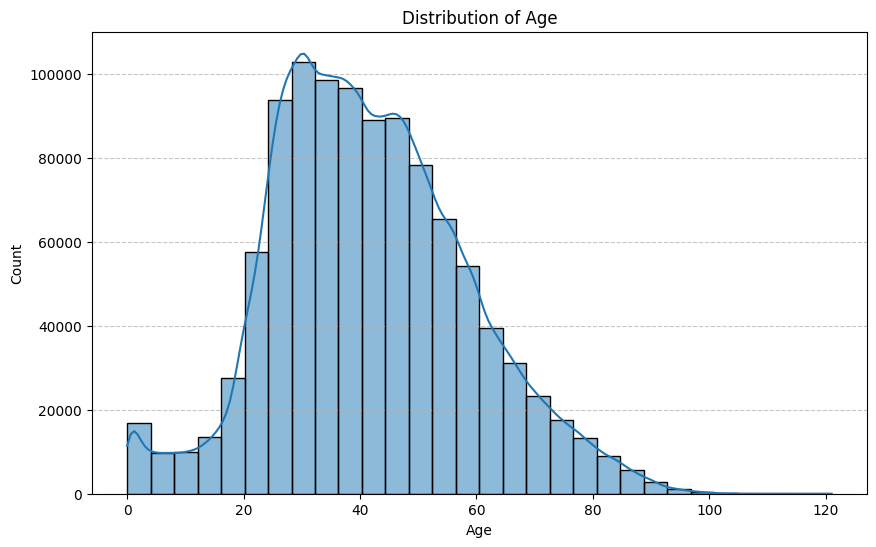

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\sujal\AppData\Local\Temp\ipykernel_18528\3248985919.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\sujal\AppData\Local\Temp\ipykernel_18528\3248985919.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\sujal\AppData\Local\Temp\ipykernel_18528\3248985919.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\sujal\AppData\Local\Temp\ipykernel_18528\3248985919.py:8: FutureWarning: 

Passing `pale

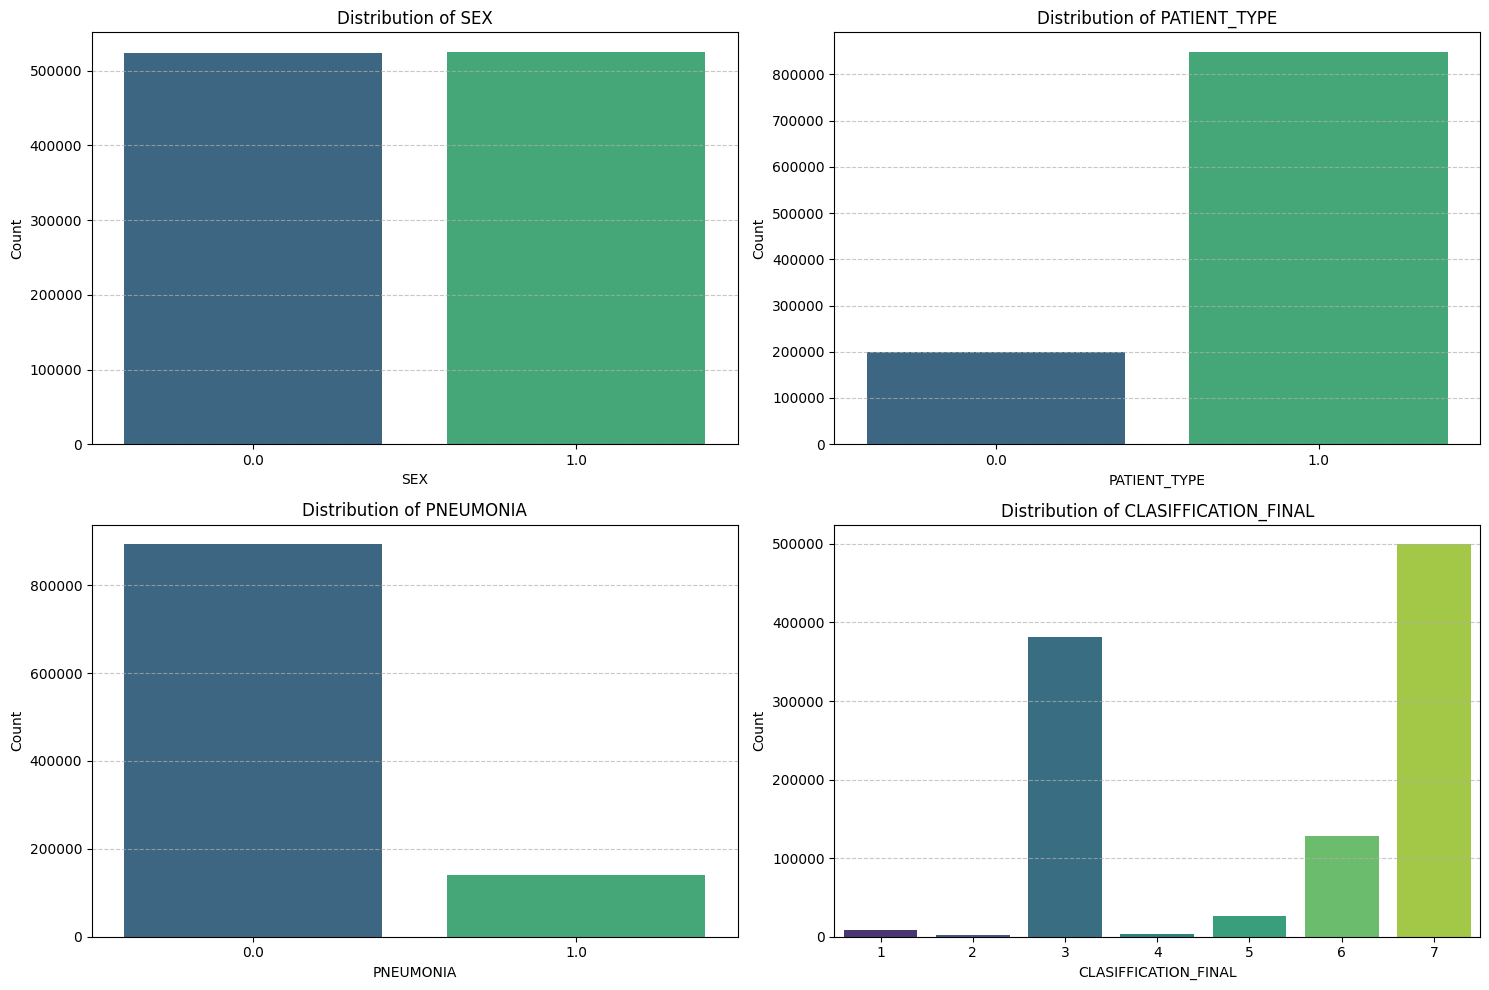

In [5]:
# Count plots for key binary/categorical features

binary_features_to_plot = ['SEX', 'PATIENT_TYPE', 'PNEUMONIA', 'CLASIFFICATION_FINAL']

plt.figure(figsize=(15, 10))
for i, col in enumerate(binary_features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\sujal\AppData\Local\Temp\ipykernel_18528\3061846891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CLASIFFICATION_FINAL', y='AGE', data=df, palette='coolwarm')


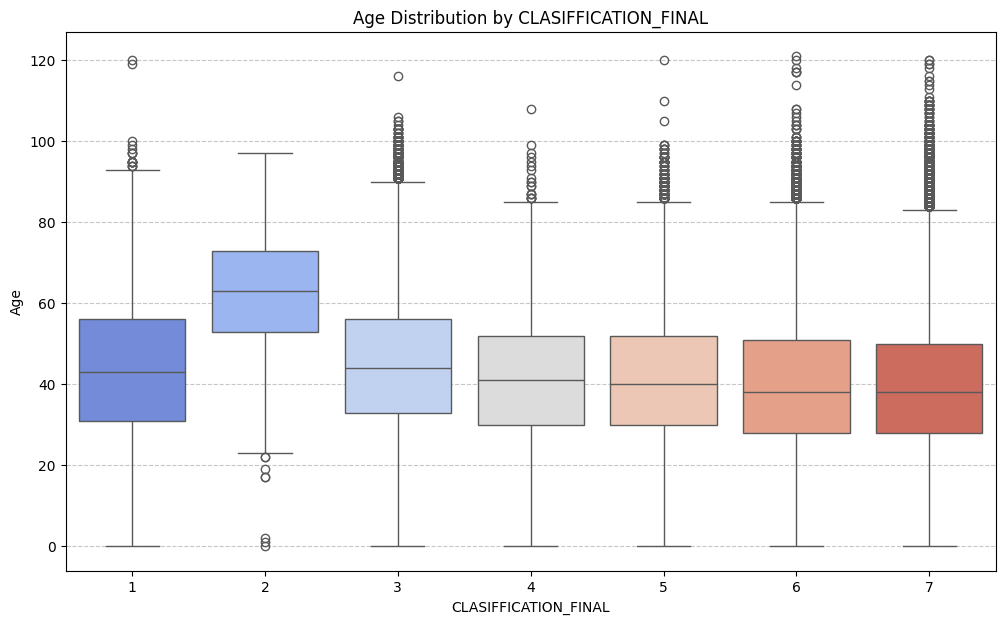

In [6]:
# Relationship between Age and CLASIFFICATION_FINAL
plt.figure(figsize=(12, 7))
sns.boxplot(x='CLASIFFICATION_FINAL', y='AGE', data=df, palette='coolwarm')
plt.title('Age Distribution by CLASIFFICATION_FINAL')
plt.xlabel('CLASIFFICATION_FINAL')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Machine Learning Model Selection and Evaluation

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define target and features
X = df.drop('CLASIFFICATION_FINAL', axis=1)
y = (df['CLASIFFICATION_FINAL'] <= 3).astype(int)

# Drop non-numeric and non-binary columns that are not suitable for direct ML or are too sparse
# 'DATE_DIED' is a datetime object and cannot be directly used unless engineered
X = X.drop(['DATE_DIED'], axis=1)

# Identify numerical and categorical columns for imputation and scaling
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist() # Should be empty after dropping DATE_DIED

# Impute missing values
# For numerical features, use the mean
mean_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = mean_imputer.fit_transform(X[numerical_cols])

# For categorical features, use the most frequent value (though should be empty here)
if categorical_cols:
    mode_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = mode_imputer.fit_transform(X[categorical_cols])

print("Missing values after imputation:")
print(X.isnull().sum().sum())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Missing values after imputation:
0
X_train_scaled shape: (734002, 19)
X_test_scaled shape: (314573, 19)



--- Training Logistic Regression ---
Accuracy: 0.6629
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.92      0.77    196979
           1       0.63      0.24      0.35    117594

    accuracy                           0.66    314573
   macro avg       0.65      0.58      0.56    314573
weighted avg       0.65      0.66      0.61    314573



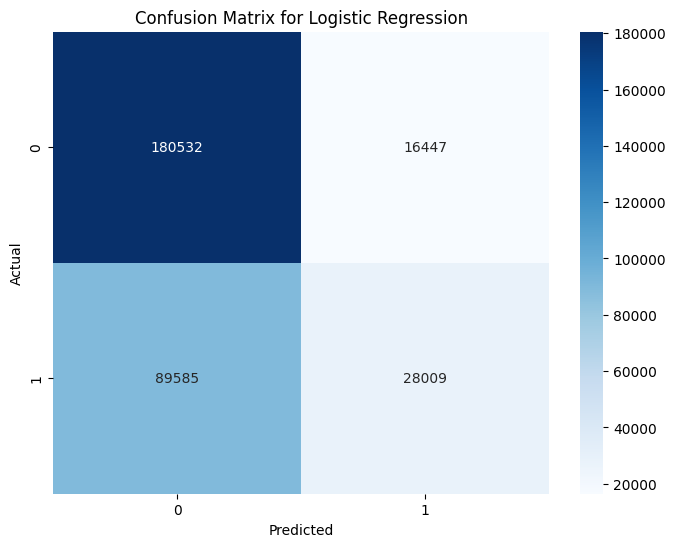


--- Training Random Forest ---
Accuracy: 0.6530
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.88      0.76    196979
           1       0.58      0.27      0.37    117594

    accuracy                           0.65    314573
   macro avg       0.62      0.58      0.56    314573
weighted avg       0.63      0.65      0.61    314573



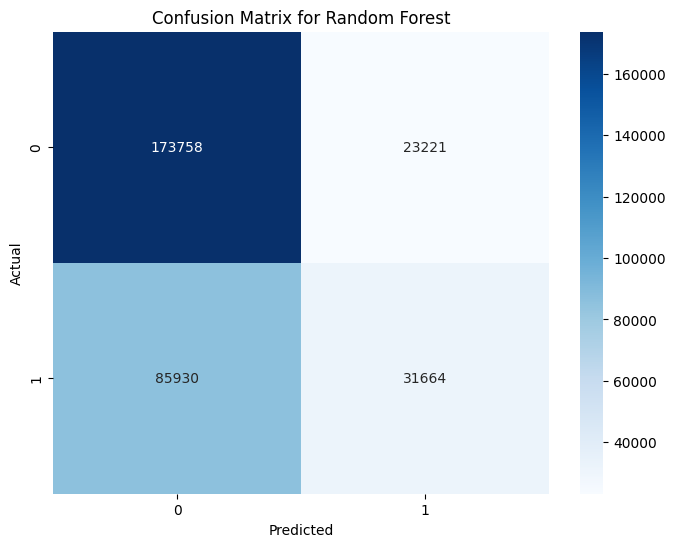


--- Training Gradient Boosting ---
Accuracy: 0.6679
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.91      0.77    196979
           1       0.64      0.26      0.37    117594

    accuracy                           0.67    314573
   macro avg       0.66      0.59      0.57    314573
weighted avg       0.66      0.67      0.62    314573



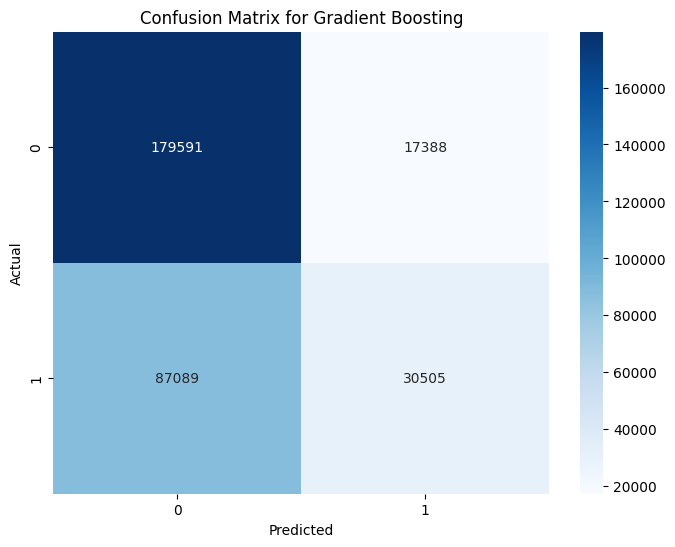


--- Best Model: Gradient Boosting with Accuracy: 0.6679 ---
Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.67      0.91      0.77    196979
           1       0.64      0.26      0.37    117594

    accuracy                           0.67    314573
   macro avg       0.66      0.59      0.57    314573
weighted avg       0.66      0.67      0.62    314573



In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Select the best model based on accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print(f"\n--- Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f} ---")
print("Classification Report for Best Model:")
print(results[best_model_name]['report'])

### Train and Evaluate Machine Learning Models

### Feature Importance Analysis for Gradient Boosting Model

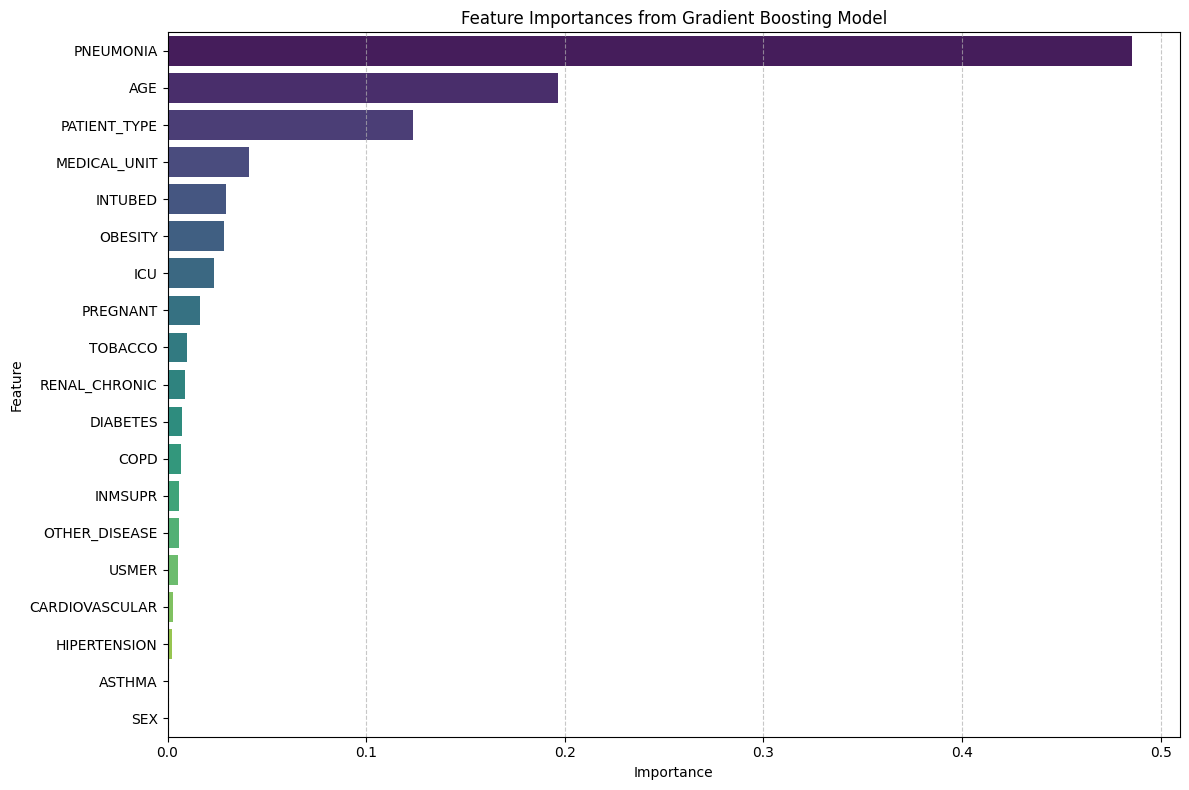

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the best model (Gradient Boosting)
best_model = models[best_model_name]

# Get feature importances
feature_importances = best_model.feature_importances_

# Get feature names from the original X DataFrame (before scaling)
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances from Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

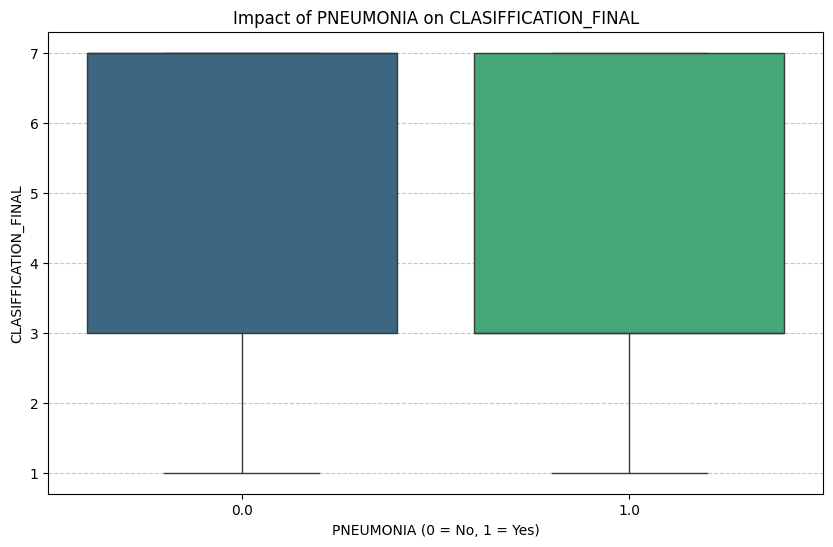

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='PNEUMONIA', y='CLASIFFICATION_FINAL', data=df, palette='viridis', hue='PNEUMONIA', legend=False)
plt.title('Impact of PNEUMONIA on CLASIFFICATION_FINAL')
plt.xlabel('PNEUMONIA (0 = No, 1 = Yes)')
plt.ylabel('CLASIFFICATION_FINAL')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
import pickle

# Get the best model
best_model = models[best_model_name]

# Save the model and scaler
with open('Model.pkl', 'wb') as file:
    pickle.dump({'model': best_model, 'scaler': scaler}, file)

print(f"Model and scaler saved to Model.pkl")

Model and scaler saved to Model.pkl


In [12]:
display(X_train.head())

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,ICU
731919,0.0,12.0,0.0,1.0,0.174649,0.0,44.0,0.015597,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.087554
129889,0.0,4.0,1.0,1.0,0.174649,0.0,26.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.087554
255680,0.0,4.0,1.0,1.0,0.174649,0.0,45.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.087554
170691,0.0,4.0,1.0,1.0,0.174649,0.0,23.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.087554
995360,1.0,12.0,0.0,0.0,0.000000,1.0,25.0,0.015597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
